In [2]:
from spatial_guidance import StrayScannerPaths, StrayScannerDataParserConfig, StrayDatasetConfig

In [ ]:
cfg = StrayScannerDataParserConfig(
)
cfg.inspect()

StrayScannerDataParserConfig
├── target: StrayScannerDataParser (type[StrayScannerDataParser])
├── propagated_fields: {} (dict[str, Any])
├── paths: 
│   └── StrayScannerPaths
│       ├── target: NoTarget (Callable[BaseConfig, TargetType])
│       ├── propagated_fields: {} (dict[str, Any])
│       ├── dataset_dir: /Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5 (<class 
│       │   'pathlib.Path'>)
│       ├── rgb_video_filename: "rgb.mp4" (<class 'str'>)
│       ├── rgb_dir: "rgb" (<class 'str'>)
│       ├── rgb_rotated_dir: "rgb_rotated" (<class 'str'>)
│       ├── depth_dir: "depth" (<class 'str'>)
│       ├── confidence_dir: "confidence" (<class 'str'>)
│       ├── camera_matrix_filename: "camera_matrix.csv" (<class 'str'>)
│       ├── odometry_filename: "odometry.csv" (<class 'str'>)
│       ├── imu_filename: "imu.csv" (<class 'str'>)
│       ├── rgb_extension: ".jpg" (<class 'str'>)
│       ├── depth_extension: ".png" (<class 'str'>)
│       └── confidence_extension: ".png" (<class 'str'>)
└── depth_unit_scale_factor: 0.001 (<class 'float'>)

In [10]:
parser = cfg.setup_target()

In [11]:
parser.get_intrinsics()

array([[1.3459686e+03, 0.0000000e+00, 9.6410077e+02],
       [0.0000000e+00, 1.3459686e+03, 7.1684204e+02],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00]])

In [12]:
frame_count = parser.get_frame_count()

In [13]:
import numpy as np

poses = parser.get_poses()

assert isinstance(poses, list)
assert len(poses) == parser.get_frame_count()
assert all(isinstance(p, np.ndarray) for p in poses)
assert all(p.shape == (4, 4) for p in poses)

In [14]:
parser.get_imu_data().shape

(2196, 7)

In [15]:
parser.get_depth_frames()[42:69:10]

[PosixPath('/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5/depth/000042.png'),
 PosixPath('/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5/depth/000052.png'),
 PosixPath('/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5/depth/000062.png')]

In [16]:
parser.get_rgb_frames()[42:69:10]

[PosixPath('/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5/rgb/000042.jpg'),
 PosixPath('/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5/rgb/000052.jpg'),
 PosixPath('/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/.data/SmartAIs Recorded Data/5/rgb/000062.jpg')]

In [ ]:
ds_config = StrayDatasetConfig(
    data_parser_config=StrayScannerDataParserConfig(
        paths=StrayScannerPaths(
            dataset_dir="SmartAIs Recorded Data/5"  # relative to root/.data
        )
    ),
    is_rotated=True,
)
ds_config.inspect()

SyntaxError: '(' was never closed (3052043385.py, line 1)

In [19]:
ds = ds_config.setup_target()

In [20]:
from matplotlib import pyplot as plt

print(ds.get_rgb(42).shape)
print(ds.get_depth(42).shape)

(1920, 1440, 3)
(256, 192)


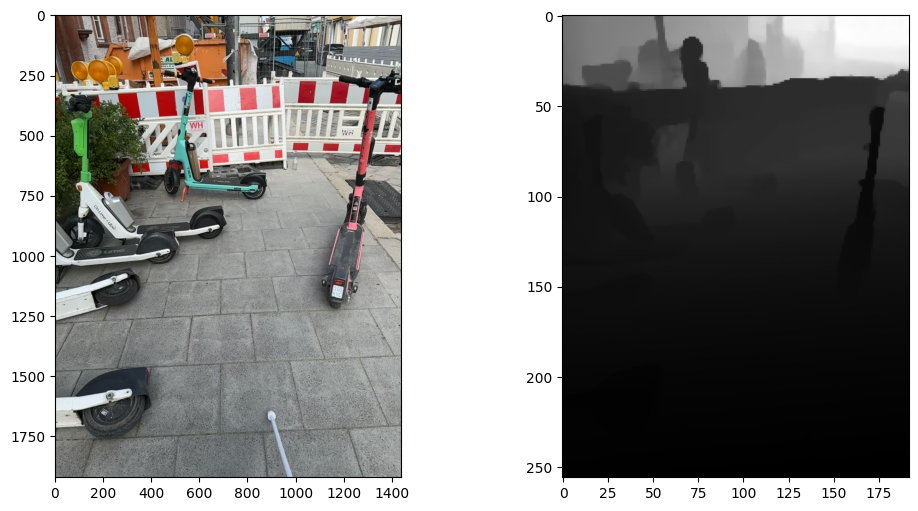

In [24]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(ds.get_rgb(420))
ax2.imshow(ds.get_depth(420), cmap='gray')

In [25]:
from utils import PathConfig


from google import genai
from google.genai import types

client = genai.Client(api_key=PathConfig().get_api_key("GOOGLE_API_KEY"))

API key 'GOOGLE_API_KEY' loaded successfully

In [26]:
model_name = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}


bounding_box_system_instructions = """
    Return bounding boxes as a JSON array with labels. Never return masks or code fencing. Limit to 25 objects.
    If an object is present multiple times, name them according to their unique characteristic (colors, size, position, unique characteristics, etc..).
    """

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

In [33]:
# @title Plotting Util
import json
import random
import io
from PIL import Image, ImageDraw
from PIL import ImageColor

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

# @title Parsing JSON output
def parse_json(json_output):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)

    # font = ImageFont.truetype("NotoSansCJK-Regular.ttc", size=14)

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json.loads(bounding_boxes)):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
      abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
      abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
      abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color)

    # Display the image
    return img

In [28]:
system_instructions: str = """
    [SYSTEM]
    Return bounding boxes as a JSON array of objects. Never use markdown code blocks. Limit to 25 objects.
    Focus on obstacles, navigation hazards, and important landmarks that would help a blind person.

    Prioritize detecting:
    1. Floor-level obstacles (chairs, steps, cords, etc.)
    2. Head-height hazards (hanging objects, branches, signs)
    3. Moving objects (people, vehicles, animals)
    4. Important navigation landmarks (doors, stairs, railings)
    5. Sudden elevation changes (curbs, steps, uneven surfaces)

    For each detected object, specify:
    - label: precise name with distinguishing characteristics (e.g., "red office chair with wheels")
    - box_2d: [y1, x1, y2, x2] with normalized coordinates from 0-1000
    - description: position relative to user (e.g., "directly ahead", "to your left")
    - distance: "near" (<2m), "middle" (2-5m), or "far" (>5m)
    - height: "floor-level", "knee-height", "waist-height", "chest-height", "eye-level", "overhead"
    - is_hazard: true if object poses collision/trip risk, false otherwise
    - guidance: brief instruction for safe navigation (e.g., "step right to avoid")
    """

prompt: str = (
        "Analyze this scene for a blind person. Identify all obstacles, hazards, and important landmarks. "
        "For each object, provide precise location, distance, height, and whether it's a navigation hazard. "
        "Include detailed spatial guidance that would help someone safely navigate this environment. "
        "Return a structured JSON array with all relevant information."
    )

In [29]:
im = Image.fromarray(ds.get_rgb(420))
# im.thumbnail([640,640], Image.Resampling.LANCZOS)

response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
    )
)

In [30]:
response

GenerateContentResponse(candidates=[Candidate(content=Content(parts=[Part(video_metadata=None, thought=None, code_execution_result=None, executable_code=None, file_data=None, function_call=None, function_response=None, inline_data=None, text='```json\n[\n  {\n    "label": "Green-handle scooter",\n    "box_2d": [\n      166,\n      2,\n      467,\n      285\n    ],\n    "distance": "1.5 meters",\n    "height": "1 meter",\n    "navigational_hazard": true,\n    "spatial_guidance": "The green-handled scooter is directly in front of you, approximately 1.5 meters away. It is about 1 meter tall and poses a tripping hazard. Proceed with caution."\n  },\n  {\n    "label": "White scooter",\n    "box_2d": [\n      376,\n      0,\n      541,\n      493\n    ],\n    "distance": "1.8 meters",\n    "height": "0.8 meters",\n    "navigational_hazard": true,\n    "spatial_guidance": "To your left, about 1.8 meters away, is a white scooter. It is approximately 0.8 meters tall and could be an obstacle. Be

(1440, 1920)


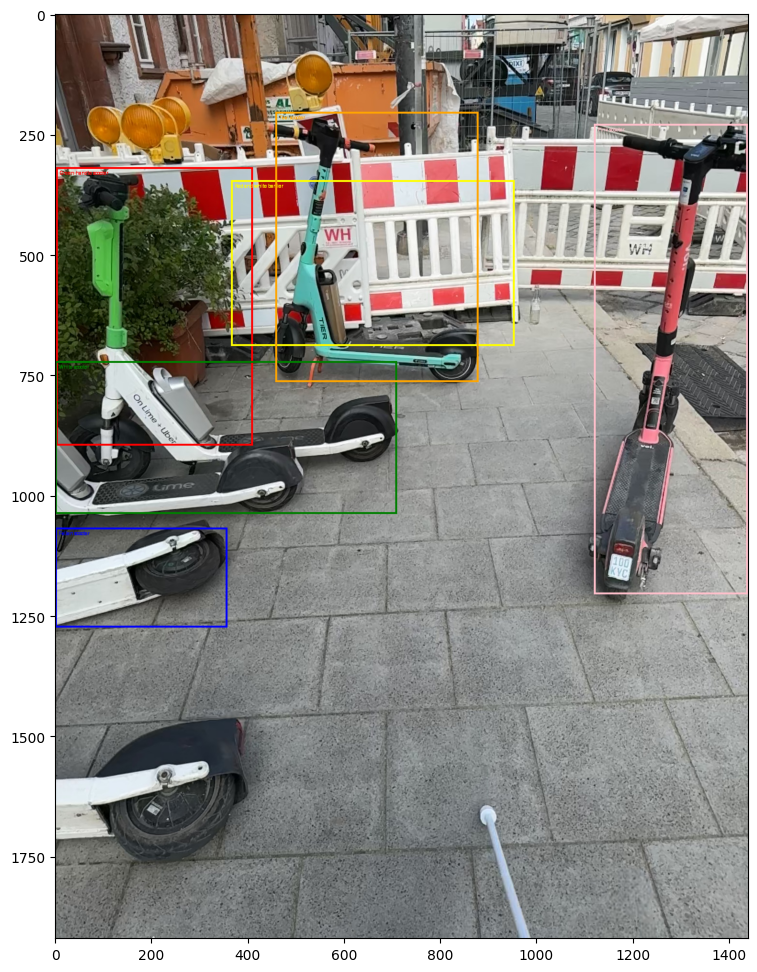

In [36]:
img = plot_bounding_boxes(im, response.text)
plt.figure(figsize=(24, 12))
plt.imshow(img)

In [38]:
print(response.text)

```json
[
  {
    "label": "Green-handle scooter",
    "box_2d": [
      166,
      2,
      467,
      285
    ],
    "distance": "1.5 meters",
    "height": "1 meter",
    "navigational_hazard": true,
    "spatial_guidance": "The green-handled scooter is directly in front of you, approximately 1.5 meters away. It is about 1 meter tall and poses a tripping hazard. Proceed with caution."
  },
  {
    "label": "White scooter",
    "box_2d": [
      376,
      0,
      541,
      493
    ],
    "distance": "1.8 meters",
    "height": "0.8 meters",
    "navigational_hazard": true,
    "spatial_guidance": "To your left, about 1.8 meters away, is a white scooter. It is approximately 0.8 meters tall and could be an obstacle. Be aware of its position as you move forward."
  },
  {
    "label": "Fallen scooter",
    "box_2d": [
      556,
      0,
      664,
      248
    ],
    "distance": "2.2 meters",
    "height": "0.3 meters",
    "navigational_hazard": true,
    "spatial_guidance": "Furt

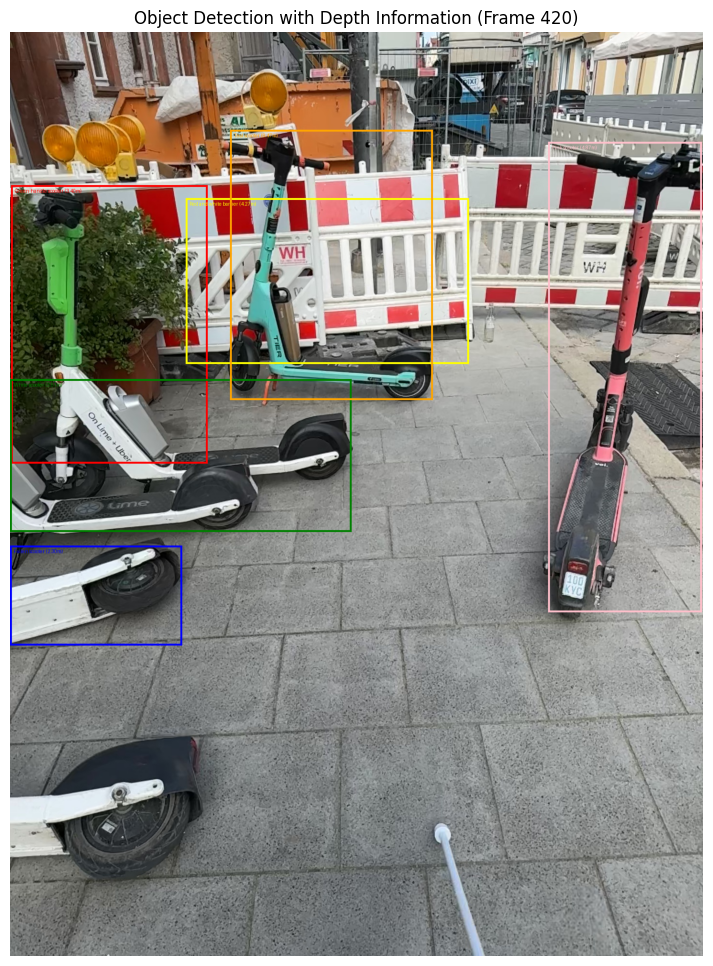


Detected objects with depth measurements:
1. Green-handle scooter
   - Estimated depth: 3.40m
   - Distance category: middle
   - Is hazard: Unknown
   - Navigation guidance: The green-handled scooter is directly in front of you, approximately 1.5 meters away. It is about 1 meter tall and poses a tripping hazard. Proceed with caution.

2. White scooter
   - Estimated depth: 3.51m
   - Distance category: middle
   - Is hazard: Unknown
   - Navigation guidance: To your left, about 1.8 meters away, is a white scooter. It is approximately 0.8 meters tall and could be an obstacle. Be aware of its position as you move forward.

3. Fallen scooter
   - Estimated depth: 2.30m
   - Distance category: middle
   - Is hazard: Unknown
   - Navigation guidance: Further to your left, around 2.2 meters away, a scooter is lying on the ground. It is only about 0.3 meters high, making it a significant tripping hazard. Exercise extreme caution in this area.

4. Red and white barrier
   - Estimated depth: 

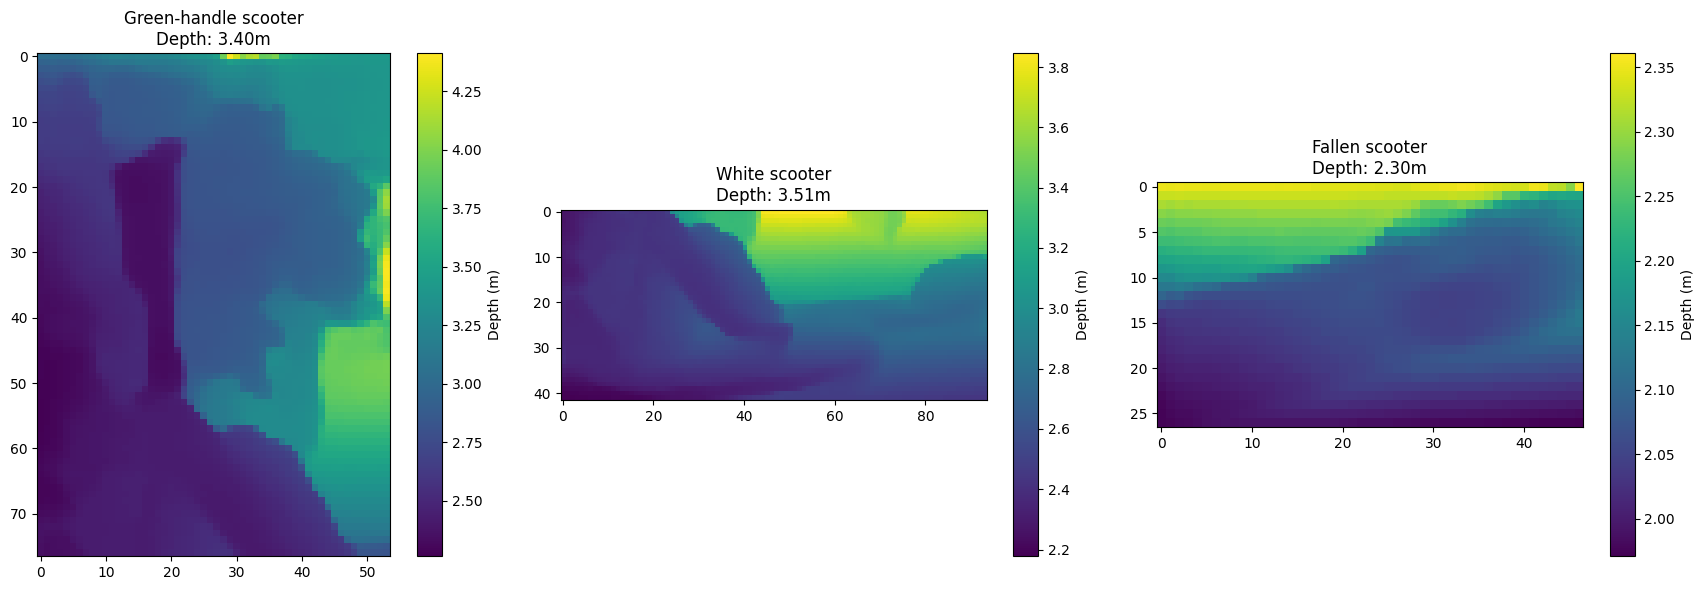

In [40]:
# Add cell to test_stray.ipynb
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def get_depth_from_bbox(depth_image, bbox, percentile=90):
    """
    Extract the depth value at the specified percentile from a bounding box region.

    Args:
        depth_image: Depth image as numpy array
        bbox: Bounding box coordinates [y1, x1, y2, x2] in normalized format (0-1000)
        percentile: Percentile value to extract (default: 95)

    Returns:
        The depth value at the specified percentile
    """
    height, width = depth_image.shape

    # Convert normalized coordinates to absolute pixel coordinates
    y1 = max(0, int(bbox[0]/1000 * height))
    x1 = max(0, int(bbox[1]/1000 * width))
    y2 = min(height, int(bbox[2]/1000 * height))
    x2 = min(width, int(bbox[3]/1000 * width))

    # Fix coordinates if they're out of order
    if x1 > x2:
        x1, x2 = x2, x1
    if y1 > y2:
        y1, y2 = y2, y1

    # Extract the depth values in the bounding box
    depth_region = depth_image[y1:y2, x1:x2]

    # Filter out zero values (invalid depth readings)
    valid_depths = depth_region[depth_region > 0]

    if valid_depths.size == 0:
        return None  # No valid depth values

    # Calculate the specified percentile
    depth_value = np.percentile(valid_depths, percentile)

    return depth_value

def enhance_detections_with_depth(detections_json, depth_image):
    """
    Enhance the detection results with actual depth information.

    Args:
        detections_json: JSON string or parsed list of detection objects
        depth_image: Depth image as numpy array

    Returns:
        Enhanced list of detections with actual depth measurements
    """
    # Parse JSON if it's a string
    if isinstance(detections_json, str):
        try:
            # Handle markdown fencing if present
            lines = detections_json.splitlines()
            for i, line in enumerate(lines):
                if line == "```json":
                    detections_json = "\n".join(lines[i+1:])
                    detections_json = detections_json.split("```")[0]
                    break
            detections = json.loads(detections_json)
        except json.JSONDecodeError:
            import re
            json_match = re.search(r'\[.*\]', detections_json, re.DOTALL)
            if json_match:
                try:
                    detections = json.loads(json_match.group(0))
                except json.JSONDecodeError:
                    return []
            else:
                return []
    else:
        detections = detections_json

    # Enhance each detection with depth information
    for detection in detections:
        if "box_2d" in detection:
            depth_value = get_depth_from_bbox(depth_image, detection["box_2d"])
            if depth_value is not None:
                # Convert depth value to meters (adjust this based on your depth unit)
                # Assuming the depth is already in meters or has a known conversion factor
                detection["actual_depth_meters"] = float(depth_value)

                # Categorize based on actual depth
                if depth_value < 2:
                    detection["actual_distance"] = "near"
                elif depth_value < 5:
                    detection["actual_distance"] = "middle"
                else:
                    detection["actual_distance"] = "far"

    return detections

def visualize_with_depth(image, detections, depth_image=None):
    """
    Visualize detections with enhanced depth information.

    Args:
        image: PIL Image to visualize
        detections: List of detection dictionaries
        depth_image: Optional depth image as numpy array

    Returns:
        PIL Image with visualized detections
    """
    img_copy = image.copy()
    width, height = img_copy.size
    draw = ImageDraw.Draw(img_copy)

    colors = [
        'red', 'green', 'blue', 'yellow', 'orange', 'pink', 'purple',
        'brown', 'gray', 'beige', 'turquoise', 'cyan', 'magenta', 'lime',
        'navy', 'maroon', 'teal', 'olive', 'coral', 'lavender'
    ] + list(ImageColor.colormap.keys())

    for i, detection in enumerate(detections):
        color = colors[i % len(colors)]

        # Extract coordinates
        box = detection.get("box_2d", [0, 0, 0, 0])
        abs_y1 = int(box[0]/1000 * height)
        abs_x1 = int(box[1]/1000 * width)
        abs_y2 = int(box[2]/1000 * height)
        abs_x2 = int(box[3]/1000 * width)

        # Fix coordinates if they're out of order
        if abs_x1 > abs_x2:
            abs_x1, abs_x2 = abs_x2, abs_x1
        if abs_y1 > abs_y2:
            abs_y1, abs_y2 = abs_y2, abs_y1

        # Draw the bounding box
        draw.rectangle(((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4)

        # Create label text with depth information
        label_text = detection.get("label", "Unknown")
        if "actual_depth_meters" in detection:
            label_text += f" ({detection['actual_depth_meters']:.2f}m)"

        # Draw the label
        draw.text((abs_x1 + 8, abs_y1 + 6), label_text, fill=color)

    return img_copy

# Apply this to our detection results
frame_index = 420
rgb_image = ds.get_rgb(frame_index)
depth_image = ds.get_depth(frame_index)
pil_image = Image.fromarray(rgb_image)

# Get the enhanced detections
enhanced_detections = enhance_detections_with_depth(response.text, depth_image)

# Visualize with depth information
visualized_image = visualize_with_depth(pil_image, enhanced_detections, depth_image)

# Display the result
plt.figure(figsize=(16, 12))
plt.imshow(visualized_image)
plt.axis('off')
plt.title(f"Object Detection with Depth Information (Frame {frame_index})")
plt.show()

# Print detailed results
print("\nDetected objects with depth measurements:")
for i, detection in enumerate(enhanced_detections):
    print(f"{i+1}. {detection.get('label', 'Unknown')}")
    if "actual_depth_meters" in detection:
        print(f"   - Estimated depth: {detection.get('actual_depth_meters', 'N/A'):.2f}m")
        print(f"   - Distance category: {detection.get('actual_distance', 'N/A')}")
    print(f"   - Is hazard: {detection.get('is_hazard', 'Unknown')}")
    print(f"   - Navigation guidance: {detection.get('guidance', detection.get('spatial_guidance', 'N/A'))}")
    print()

# Plot depth visualization for each object
fig, axes = plt.subplots(1, min(len(enhanced_detections), 3), figsize=(18, 6))
if len(enhanced_detections) == 1:
    axes = [axes]  # Make iterable if only one subplot

for i, (ax, detection) in enumerate(zip(axes, enhanced_detections[:3])):
    box = detection.get("box_2d", [0, 0, 0, 0])
    h, w = depth_image.shape

    y1 = max(0, int(box[0]/1000 * h))
    x1 = max(0, int(box[1]/1000 * w))
    y2 = min(h, int(box[2]/1000 * h))
    x2 = min(w, int(box[3]/1000 * w))

    # Fix coordinates if needed
    if x1 > x2:
        x1, x2 = x2, x1
    if y1 > y2:
        y1, y2 = y2, y1

    # Get the depth region for this object
    depth_region = depth_image[y1:y2, x1:x2]

    # Show depth map with colorbar
    im = ax.imshow(depth_region, cmap='viridis')
    ax.set_title(f"{detection.get('label')}\nDepth: {detection.get('actual_depth_meters', 'N/A'):.2f}m")
    plt.colorbar(im, ax=ax, label='Depth (m)')

plt.tight_layout()
plt.show()